#### Recency Frequency and Monetary value (RFM)

In [1]:
import pandas as pd

df = pd.read_csv('..\\data\\processed\\master_df.csv')
print(df.shape)

(7043, 50)


RFM answers a different question: who is this customer, commercially?

A customer with 90% churn probability but zero revenue and zero referrals — you don't fight to retain them. A customer with 80% churn probability but high revenue and referrals — you throw a retention offer at them immediately.

RFM is the business prioritisation layer that sits on top of churn probability. Together they tell you: this person will churn AND they're valuable — act now.






Why these three columns specifically?

Tenure in Months as Recency proxy

In traditional RFM (e-commerce), Recency = days since last purchase. In telecom, there's no "last purchase" — customers pay monthly. So tenure is the closest signal: a customer who's been here 60 months is far more "recent" in their relationship than someone in month 2 who's already disengaged. Longer tenure = higher recency score.

Number of Referrals as Frequency proxy

In e-commerce, Frequency = number of purchases. In telecom, you don't buy repeatedly — you subscribe once. Referrals are the engagement signal: customers who refer others are actively involved with the brand. More referrals = more engaged = higher frequency score.

Total Revenue as Monetary

Straightforward — total money a customer has generated. Higher revenue = higher monetary score.


Because CLTV is a model output — IBM computed it using their own formula internally. We don't know their methodology. If we use it as an RFM input, we're building on a black box.


Building our own RFM from raw behavioural columns gives us full explainability — critical for interviews and for real business use.

In [2]:
df['Tenure in Months'].describe()

count    7043.000000
mean       32.386767
std        24.542061
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: Tenure in Months, dtype: float64

##### How does scoring work?

We use quartile-based scoring. We divide all customers into 4 equal groups (quartiles) for each dimension and assign scores 1–4.

For Recency and Monetary: higher value → higher score (4 = best)
For Frequency: same logic — more referrals → higher score

Then we combine: RFM_Score = R + F + M (sum, range 3–12)
High combined score = valuable, engaged, long-tenure customer.

In [3]:
# Step 1: Recency Score from Tenure in Months
df['R_Score'] = pd.qcut(df['Tenure in Months'], q=4, labels=[1, 2, 3, 4])

In [4]:
df['R_Score'].value_counts().sort_index()

R_Score
1    1843
2    1726
3    1719
4    1755
Name: count, dtype: int64

In [5]:
df['Number of Referrals'].value_counts().sort_index()

Number of Referrals
0     3821
1     1086
2      236
3      255
4      236
5      264
6      221
7      248
8      213
9      238
10     223
11       2
Name: count, dtype: int64

In [6]:
import numpy as np

def score_referrals(val):
    if val == 0:
        return 1
    elif val <= 2:
        return 2
    elif val <= 6:
        return 3
    else:
        return 4

df['F_Score'] = df['Number of Referrals'].apply(score_referrals)


In [7]:
df['F_Score'].value_counts().sort_index()

F_Score
1    3821
2    1322
3     976
4     924
Name: count, dtype: int64

In [8]:
df['Total Revenue'].describe()

count     7043.000000
mean      3034.379056
std       2865.204542
min         21.360000
25%        605.610000
50%       2108.640000
75%       4801.145000
max      11979.340000
Name: Total Revenue, dtype: float64

In [9]:
# Step 3: Monetary Score from Total Revenue
df['M_Score'] = pd.qcut(df['Total Revenue'], q=4, labels=[1, 2, 3, 4])

In [10]:
df['M_Score'].value_counts().sort_index()

M_Score
1    1761
2    1761
3    1760
4    1761
Name: count, dtype: int64

In [11]:
# Convert scores to int before adding
df['R_Score'] = df['R_Score'].astype(int)
df['F_Score'] = df['F_Score'].astype(int)
df['M_Score'] = df['M_Score'].astype(int)

# Combine into single RFM Score
df['RFM_Score'] = df['R_Score'] + df['F_Score'] + df['M_Score']

In [12]:
df['RFM_Score'].value_counts().sort_index()

RFM_Score
3     1231
4      506
5      830
6      697
7      778
8      786
9      820
10     628
11     479
12     288
Name: count, dtype: int64

In [13]:
# Step 5: Assign Segment Labels based on RFM_Score
def assign_segment(score):
    if score >= 10:
        return 'Champions'
    elif score >= 7:
        return 'Loyal Customers'
    elif score >= 5:
        return 'At Risk'
    else:
        return 'Lost'

df['RFM_Segment'] = df['RFM_Score'].apply(assign_segment)

In [14]:
df['RFM_Segment'].value_counts()

RFM_Segment
Loyal Customers    2384
Lost               1737
At Risk            1527
Champions          1395
Name: count, dtype: int64

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\Mujtaba Jafri\AppData\Local\Temp\ipykernel_9700\4244872825.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=segment_counts.index, y=segment_counts.values, palette='RdYlGn_r')


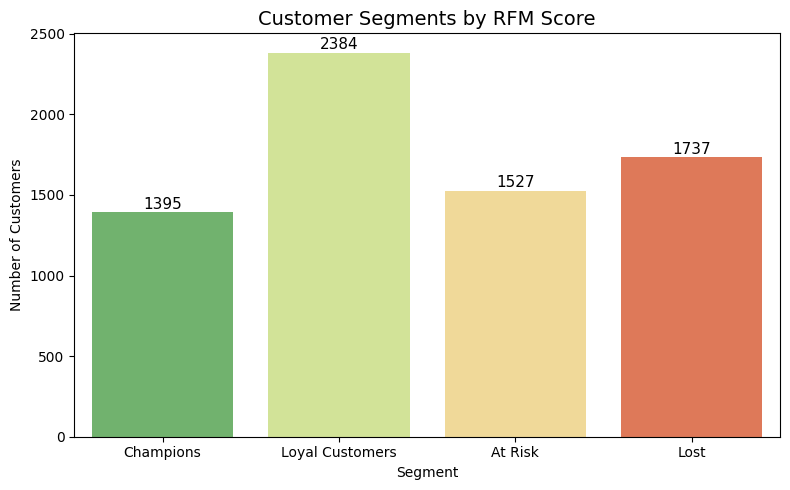

In [25]:
segment_counts = df['RFM_Segment'].value_counts().reindex(['Champions', 'Loyal Customers', 'At Risk', 'Lost'])

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=segment_counts.index, y=segment_counts.values, palette='RdYlGn_r')

for i, v in enumerate(segment_counts.values):
    ax.text(i, v + 20, str(v), ha='center', fontsize=11)

plt.title('Customer Segments by RFM Score', fontsize=14)
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

In [26]:
churn_by_segment = df.groupby('RFM_Segment')['Churn Value'].mean() * 100
churn_by_segment = churn_by_segment.reindex(['Champions', 'Loyal Customers', 'At Risk', 'Lost'])
churn_by_segment = churn_by_segment.round(1)

print(churn_by_segment)

RFM_Segment
Champions           6.5
Loyal Customers    18.4
At Risk            30.1
Lost               50.6
Name: Churn Value, dtype: float64


This is a strong result. Churn rate increases cleanly and dramatically across every segment:

Champions: 6.5% — almost nobody leaves
Loyal Customers: 18.4% — moderate risk
At Risk: 30.1% — nearly 1 in 3 are leaving
Lost: 50.6% — more than half are already gone


Compare this to the overall churn rate of 26.5% from your EDA. Champions are 4x better than average. Lost customers are 2x worse than average.


C:\Users\Mujtaba Jafri\AppData\Local\Temp\ipykernel_9700\3430418941.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=churn_by_segment.index, y=churn_by_segment.values, palette='RdYlGn_r')


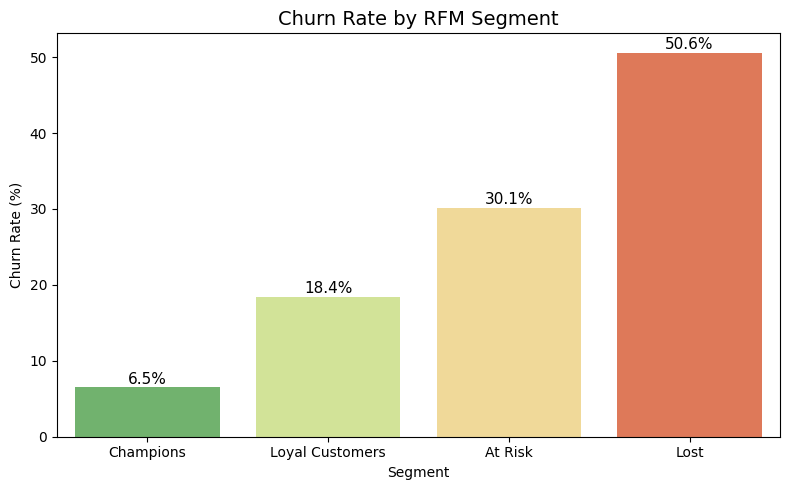

In [27]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=churn_by_segment.index, y=churn_by_segment.values, palette='RdYlGn_r')

for i, v in enumerate(churn_by_segment.values):
    ax.text(i, v + 0.5, f'{v}%', ha='center', fontsize=11)

plt.title('Churn Rate by RFM Segment', fontsize=14)
plt.xlabel('Segment')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

In [28]:
revenue_by_segment = df.groupby('RFM_Segment')['Total Revenue'].mean()
revenue_by_segment = revenue_by_segment.reindex(['Champions', 'Loyal Customers', 'At Risk', 'Lost'])
revenue_by_segment = revenue_by_segment.round(1)

print(revenue_by_segment)

RFM_Segment
Champions          6570.6
Loyal Customers    4009.2
At Risk            1405.5
Lost                288.5
Name: Total Revenue, dtype: float64


C:\Users\Mujtaba Jafri\AppData\Local\Temp\ipykernel_9700\2215132676.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=revenue_by_segment.index, y=revenue_by_segment.values, palette='RdYlGn_r')


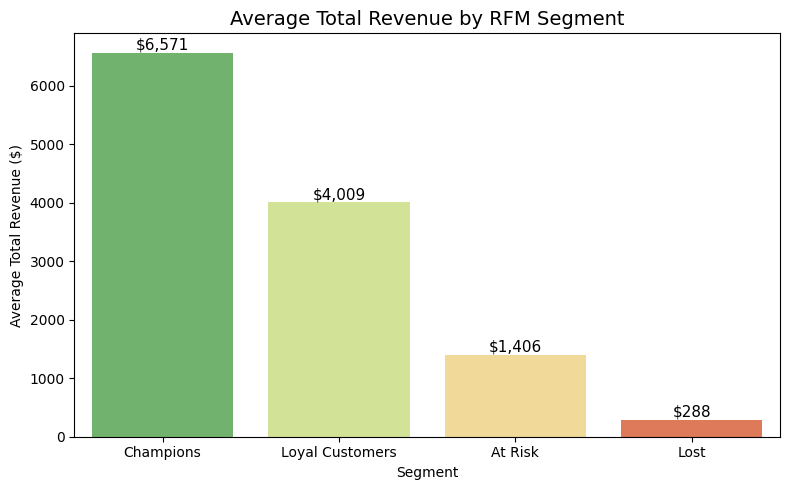

In [29]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=revenue_by_segment.index, y=revenue_by_segment.values, palette='RdYlGn_r')

for i, v in enumerate(revenue_by_segment.values):
    ax.text(i, v + 50, f'${v:,.0f}', ha='center', fontsize=11)

plt.title('Average Total Revenue by RFM Segment', fontsize=14)
plt.xlabel('Segment')
plt.ylabel('Average Total Revenue ($)')
plt.tight_layout()
plt.show()

In [30]:
summary = pd.DataFrame({
    'Customer Count': df['RFM_Segment'].value_counts(),
    'Churn Rate (%)': churn_by_segment,
    'Avg Revenue ($)': revenue_by_segment
}).reindex(['Champions', 'Loyal Customers', 'At Risk', 'Lost'])

print(summary)

                 Customer Count  Churn Rate (%)  Avg Revenue ($)
RFM_Segment                                                     
Champions                  1395             6.5           6570.6
Loyal Customers            2384            18.4           4009.2
At Risk                    1527            30.1           1405.5
Lost                       1737            50.6            288.5


In [31]:
summary = pd.DataFrame({
    'Customer Count': df['RFM_Segment'].value_counts().reindex(['Champions', 'Loyal Customers', 'At Risk', 'Lost']).values,
    'Churn Rate (%)': churn_by_segment.values,
    'Avg Revenue ($)': revenue_by_segment.values.round(0)
}, index=['Champions', 'Loyal Customers', 'At Risk', 'Lost'])

summary.style\
    .format({
        'Customer Count': '{:,}',
        'Churn Rate (%)': '{:.1f}%',
        'Avg Revenue ($)': '${:,.0f}'
    })\
    .background_gradient(subset=['Churn Rate (%)'], cmap='RdYlGn_r')\
    .background_gradient(subset=['Avg Revenue ($)'], cmap='RdYlGn')\
    .set_properties(**{'font-size': '13px', 'text-align': 'center'})\
    .set_table_styles([{
        'selector': 'th',
        'props': [('font-size', '13px'), ('text-align', 'center'), ('padding', '8px 20px')]
    }])

,Customer Count,Churn Rate (%),Avg Revenue ($)
Champions,"1,395",6.5%,"$6,571"
Loyal Customers,"2,384",18.4%,"$4,009"
At Risk,"1,527",30.1%,"$1,406"
Lost,"1,737",50.6%,$288


In [33]:
print(df.columns.tolist())
print(df.shape)

['Customer ID', 'Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'Number of Dependents', 'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Satisfaction Score', 'Customer Status', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Category', 'Churn Reason', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'RFM_Segment']
(7043, 55)


In [34]:
df[['Customer ID', 'RFM_Segment']].to_csv(
    'e:\\Projects\\customer-churn-project\\data\\processed\\rfm_segments.csv',
    index=False
)
print("Saved")

Saved
